## ***Heart Disease Prediction using Logistic Regression***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
print(df)

      male  age  education  ...  heartRate  glucose  TenYearCHD
0        1   39        4.0  ...       80.0     77.0           0
1        0   46        2.0  ...       95.0     76.0           0
2        1   48        1.0  ...       75.0     70.0           0
3        0   61        3.0  ...       65.0    103.0           1
4        0   46        3.0  ...       85.0     85.0           0
...    ...  ...        ...  ...        ...      ...         ...
4235     0   48        2.0  ...       84.0     86.0           0
4236     0   44        1.0  ...       86.0      NaN           0
4237     0   52        2.0  ...       80.0    107.0           0
4238     1   40        3.0  ...       67.0     72.0           0
4239     0   39        3.0  ...       85.0     80.0           0

[4240 rows x 16 columns]


In [8]:
df.dropna(axis = 0, inplace = True)
df.head()

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [10]:
print(df.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


In [11]:
X = np.asarray(df[['age', 'Sex_male', 'cigsPerDay',
                           'totChol', 'sysBP', 'glucose']])
y = np.asarray(df['TenYearCHD'])

In [12]:
from sklearn import preprocessing
X = preprocessing.StandardScaler().fit(X).transform(X)

In [13]:
# Trainng the data / Spliting the data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 4)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3000, 6) (751, 6) (3000,) (751,)


In [17]:
print(np.isnan(X_train).sum())

0


/tmp/ipykernel_28279/2951697134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'TenYearCHD', data = df, palette = 'BuGn_r')


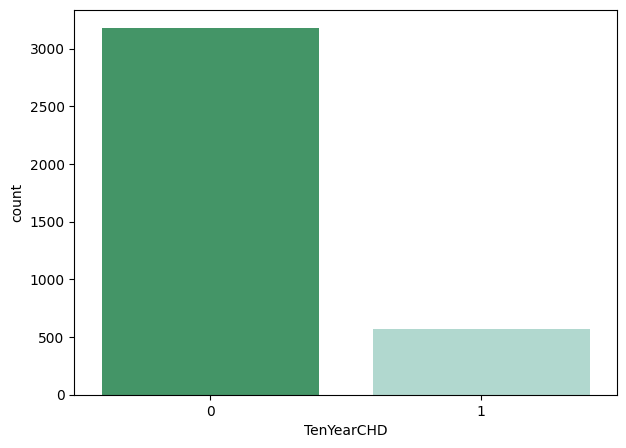

In [19]:
plt.figure(figsize = (7, 5))
sns.countplot(x = 'TenYearCHD', data = df, palette = 'BuGn_r')
plt.show()

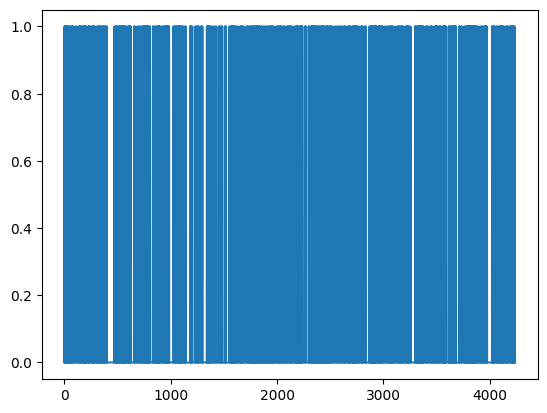

In [20]:
# Counting number of patients affected by CHD
laste = df['TenYearCHD'].plot()
plt.show(laste)

## Fitting the Logitic regression model to find out the disease affected people

In [21]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [22]:
# Evaluating the model now :
print(accuracy_score(y_test, y_pred))

0.848202396804261


              precision    recall  f1-score   support

           0       0.86      0.99      0.92       636
           1       0.53      0.09      0.15       115

    accuracy                           0.85       751
   macro avg       0.69      0.54      0.53       751
weighted avg       0.81      0.85      0.80       751



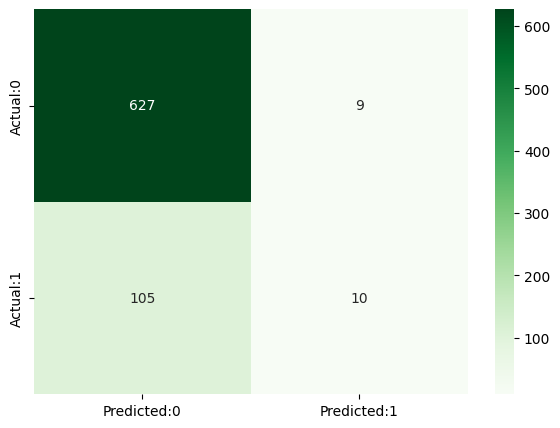

In [23]:
# Confusion matrix for evaluating the model performance
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (7, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Greens')

plt.show()

In [24]:
pip install imbalanced-learn

In [26]:
# Using SMOTE To solve the issue for imbalanced datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [27]:
# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [31]:
print(X_train_smote)

[[ 0.52494496 -0.89060984 -0.75181229  0.92952821 -0.23570021 -0.16369438]
 [ 0.99567725  1.12282613  0.9417765  -0.37920033 -0.16771194 -0.07924328]
 [-0.76956884 -0.89060984  0.5183793  -0.08586463 -1.48215173 -0.16369438]
 ...
 [ 0.8793243   1.12282613 -0.75181229  1.65413567  0.6664555  -0.37052682]
 [ 1.70177569 -0.89060984 -0.75181229  1.20562109 -0.65093135  0.13553054]
 [-0.26277459  1.12282613 -0.75181229  0.90804599  0.84882526  0.10328958]]


In [32]:
print(y_train_smote)

[0 1 0 ... 1 1 1]


In [33]:
model = LogisticRegression()
model.fit(X_train_smote, y_train_smote)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.64      0.76       636
           1       0.26      0.68      0.37       115

    accuracy                           0.65       751
   macro avg       0.59      0.66      0.56       751
weighted avg       0.82      0.65      0.70       751



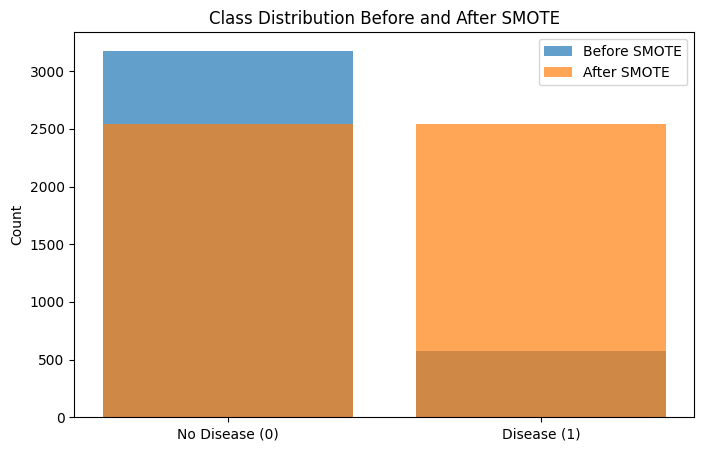

In [35]:
plt.figure(figsize=(8, 5))

original_counts = df['TenYearCHD'].value_counts()
balanced_counts = pd.Series(y_train_smote).value_counts()

plt.bar(['No Disease (0)', 'Disease (1)'],
        original_counts.values,
        alpha=0.7,
        label='Before SMOTE')

plt.bar(['No Disease (0)', 'Disease (1)'],
        balanced_counts.values,
        alpha=0.7,
        label='After SMOTE')

plt.title('Class Distribution Before and After SMOTE')
plt.ylabel('Count')
plt.legend()

# Removed output_dir as it was not defined. The file will be saved in the current directory.
plt.savefig("class_distribution_smote.png", bbox_inches='tight')
plt.show()

## **After applying Smote now the datasets are approximatly equal solving the imbalanced datasets issue**